# 01 — Data audit: 15-min analytical record + crown thermocouple

**Purpose:** understand the raw client data, find sensor faults, decide cleaning rules, and check that SFC recomputed from 15-min data matches the client's baseline.
Cleaning rules live in `src/data_prep.py`; this notebook shows the evidence behind them and writes `data/processed/`.

**Inputs (data/raw):**
- `Analytical_Record_Creation_EE_60TPD_updated-2.xlsx`: 15-min record, sheet `result` (+ `Sheet1` = plant's model design)
- `DCS_60_TPD_MelterCrown3.xlsx`: 1-min crown thermocouple TC MC3
- `SFC_60_TPD_Baseline_Calculation_Sep-25_to_Jul-26_updated.xlsx`: client baseline (daily)

**Outputs (data/processed):** `ar_15min_clean.parquet`, `daily_clean.parquet`, `daily_clean.csv`

In [1]:
import sys; sys.path.insert(0, '../src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import data_prep as dp
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)

# Chart style: reference palette (dataviz skill), recessive grid, no top/right spines
BLUE, ORANGE = '#2a78d6', '#eb6834'
INK, INK2, MUTED, GRID, SURF = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURF, 'axes.facecolor': SURF, 'axes.edgecolor': MUTED,
    'axes.labelcolor': INK2, 'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.grid': True,
    'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'lines.linewidth': 1.6, 'font.size': 10, 'axes.titlesize': 11, 'axes.titlecolor': INK,
    'legend.frameon': False, 'figure.dpi': 110})

## 1. Raw 15-min record and the plant's model design (Sheet1)

In [2]:
raw = dp.load_ar_raw()
print(raw.shape, raw.ts.min(), '->', raw.ts.max())
display(pd.read_excel(dp.AR_FILE, sheet_name='Sheet1').fillna(''))
raw.describe().T.round(2)

(43624, 14) 2025-09-01 00:00:00 -> 2026-09-30 23:45:00


,Unnamed: 0,Unnamed: 1,Unnamed: 2,input - automated,Input - operator,recommendation
0,2 models,1),one for gas,ncv (uems mqtt),"draw, optical temp, cullet %","ng flow, air-fuel ratio"
1,,2),one for electricity,MB3 temp(dcs autoloader),"draw, cullet %",barrier boosting (kwh)
2,,,,,,
3,,,,,,
4,,,,"have threshold limits for gas, boosting, temps",,


,count,mean,min,25%,50%,75%,max,std
ts,43624,2026-03-22 06:41:14.298551,2025-09-01 00:00:00,2025-12-19 20:26:15,2026-03-25 05:52:30,2026-06-25 20:18:45,2026-09-30 23:45:00,NaN
bb_kwh,43528.0,92.621226,0.0,76.5,94.2,110.0,194.0,26.611121
mb_kwh,43527.0,78.690578,0.0,76.3,76.4,76.6,538.0,11.087663
ncv,43138.0,8786.951831,0.0,9149.0,9477.0,10073.0,10454.0,2750.040857
cullet_pct,43624.0,17.919952,16.0,17.0,18.0,19.0,20.0,1.336463
opt_temp,30392.0,1578.402079,1473.0,1574.0,1575.0,1576.0,15757.0,230.095759
sec_air,43379.0,1011.271136,569.756246,982.315249,1008.54057,1037.635268,1378.167816,41.415931
ng_scm,43379.0,83.137349,45.370223,78.961705,82.503604,86.702022,165.50925,5.333255
mb3_temp,43379.0,1320.503449,1305.121141,1319.235423,1320.262207,1321.742333,1327.889445,1.980122
afr,43379.0,12.193721,6.475792,11.757477,12.186075,12.602688,22.427204,0.614929


## 2. Duplicate timestamps
5,704 timestamps appear twice. The duplicate rows are identical in every column **except** `opt_temp`, so the optical temperature was joined from a source with more than one reading per slot. Rule: one row per timestamp, `opt_temp` averaged.

In [3]:
dup = raw[raw.ts.duplicated(keep=False)]
print('duplicate rows:', len(dup), '| distinct timestamps duplicated:', dup.ts.nunique(), '| days affected:', dup.ts.dt.date.nunique())
g = dup.groupby('ts')
pd.Series({c: int((g[c].nunique(dropna=False) > 1).sum()) for c in raw.columns if c != 'ts'}, name='timestamps where duplicates differ')

duplicate rows: 11176 | distinct timestamps duplicated: 5472 | days affected: 160


bb_kwh           0
mb_kwh           0
ncv              0
cullet_pct       0
opt_temp      5472
sec_air          0
ng_scm           0
mb3_temp         0
afr              0
seed_count       0
seed_spec        0
draw_kg          0
sfc_record       0
Name: timestamps where duplicates differ, dtype: int64

## 3. Zero / missing runs (sensor not working)
Zeros are sensor faults, not real values. Longest runs per column, after de-duplication:

In [4]:
q0 = raw.groupby('ts').first()
def runs(s, cond, min_len=4):
    c = cond(s).fillna(False).to_numpy(); out = []; i = 0
    while i < len(c):
        if c[i]:
            j = i
            while j < len(c) and c[j]: j += 1
            if j - i >= min_len: out.append((s.index[i], s.index[j-1], (j-i)/4))
            i = j
        else: i += 1
    return out
rows = []
for col in ['ncv','bb_kwh','mb_kwh','ng_scm','sec_air','mb3_temp','opt_temp','draw_kg']:
    for kind, cond in [('zero', lambda s: s == 0), ('missing', lambda s: s.isna())]:
        for st, en, h in sorted(runs(q0[col], cond), key=lambda r: -r[2])[:3]:
            rows.append(dict(column=col, kind=kind, start=st, end=en, hours=h))
pd.DataFrame(rows)

,column,kind,start,end,hours
0,ncv,zero,2025-09-01 00:00:00,2025-10-06 15:45:00,856.00
1,ncv,missing,2025-10-06 16:00:00,2025-10-08 12:30:00,44.75
2,ncv,missing,2026-07-14 13:00:00,2026-07-15 11:30:00,22.75
3,ncv,missing,2026-07-13 16:00:00,2026-07-14 10:45:00,19.00
4,bb_kwh,zero,2026-07-17 05:00:00,2026-07-17 08:45:00,4.00
5,bb_kwh,zero,2025-10-02 15:00:00,2025-10-02 17:45:00,3.00
6,bb_kwh,zero,2025-10-02 00:45:00,2025-10-02 02:45:00,2.25
7,bb_kwh,missing,2026-09-30 00:00:00,2026-09-30 23:45:00,24.00
8,mb_kwh,zero,2025-09-20 09:00:00,2025-09-20 16:30:00,7.75
9,mb_kwh,zero,2025-09-23 12:30:00,2025-09-23 14:00:00,1.75


**Reading the table**
- **NCV = 0 from 1 Sep to 6 Oct 2025** (856 h), and missing 6–8 Oct and 13–16 Jul 2026. For daily SFC, these days use the baseline workbook's daily NCV. They are excluded from training the 15-min gas model.
- **Draw is missing for all of Sep 2026**, so SFC for September can't be computed yet.
- **Optical temperature** has multi-day gaps, mostly on days 1–12 of a month, starting at 06:00. That pattern suggests a day/month swap (DD/MM vs MM/DD) in the source log. Ask the plant for the raw optical log.
- NG, secondary air and MB3 share the same 21 DCS gaps (≤ 11 h). Interpolate gaps ≤ 1 h; leave longer gaps as missing.
- Barrier and melter boost have short zero runs (≤ 8 h), treated as sensor faults per the plant team.

## 4. Outliers and manual-entry typos

In [5]:
print('opt_temp outside 1550-1600:', q0.opt_temp[(q0.opt_temp<1550)|(q0.opt_temp>1600)].round().value_counts().to_dict())
print('mb_kwh > 200:', q0.mb_kwh[q0.mb_kwh>200].to_dict())
print('draw > 90 t:', q0.draw_kg[q0.draw_kg>90000].groupby(q0[q0.draw_kg>90000].index.date).first().to_dict())
print('opt_temp distinct values per hour:', q0.opt_temp.resample('h').nunique().value_counts().to_dict())

opt_temp outside 1550-1600: {1475.0: 8, 2576.0: 4, 1674.0: 4, 15757.0: 4, 15722.0: 4, 1476.0: 4, 1473.0: 4}
mb_kwh > 200: {Timestamp('2026-01-09 15:15:00'): 538.0, Timestamp('2026-01-09 16:00:00'): 260.0, Timestamp('2026-01-09 16:30:00'): 272.0}
draw > 90 t: {datetime.date(2025, 10, 1): 106204.0, datetime.date(2026, 6, 1): 115858.0}
opt_temp distinct values per hour: {1: 6185, 0: 3295}


- `opt_temp` values like 2576, 15757, 15722, 1674 and 1474 are typing errors of ~1575. The value changes at most once per hour, so it is a **manual hourly reading** carried forward to 15 min.
- Draw on 2025-10-01 and 2026-06-01 is exactly double the SAP value. Replaced by the baseline workbook's draw.
- One melter-boost spike (538 kWh in 15 min).

## 5. Units: check against the client baseline (daily)
The DCS tags have no units in the file. Summing the 96 values in a day reproduces the baseline's daily SCM and kWh, so **all flow and boost columns are per-15-min quantities**.

In [6]:
base = dp.load_baseline_daily()
qq = q0.copy(); qq['date'] = qq.index.normalize()
chk = qq.groupby('date').agg(ng=('ng_scm','sum'), bb=('bb_kwh','sum'), mb=('mb_kwh','sum'), n=('ng_scm','count')).join(base, how='inner')
chk = chk[chk.n == 96]
pd.DataFrame({'sum(15-min)/baseline median': [ (chk.ng/chk.base_ng_scm).median(), (chk.bb/chk.base_bb_kwh).median(), (chk.mb/chk.base_mb_kwh).median()],
              'p10': [ (chk.ng/chk.base_ng_scm).quantile(.1), (chk.bb/chk.base_bb_kwh).quantile(.1), (chk.mb/chk.base_mb_kwh).quantile(.1)],
              'p90': [ (chk.ng/chk.base_ng_scm).quantile(.9), (chk.bb/chk.base_bb_kwh).quantile(.9), (chk.mb/chk.base_mb_kwh).quantile(.9)]},
             index=['NG SCM','Barrier kWh','Melter kWh']).round(4)

,sum(15-min)/baseline median,p10,p90
NG SCM,1.0050,0.9943,1.0154
Barrier kWh,1.0021,0.9423,1.0595
Melter kWh,0.9998,0.9903,1.0098


In [7]:
print('AFR column == sec_air / ng_scm ? max abs diff =', (raw.afr - raw.sec_air/raw.ng_scm).abs().max())
print('Melter boost most common 15-min values:', raw.mb_kwh.round(1).value_counts().head(5).to_dict())

AFR column == sec_air / ng_scm ? max abs diff = 1.7763568394002505e-15
Melter boost most common 15-min values: {76.4: 10500, 76.3: 9945, 76.5: 4767, 95.5: 2651, 95.6: 2199}


- `Air_Fuel_Ratio` is exactly `SecondaryAirFlow / MelterGasFlow`. The 'secondary' column is **combustion air**, not a second gas stream (to confirm with the plant).
- Melter boost sits on a few fixed levels (57.2 → 76.4 → 95.5 kWh per 15 min), so it is a fixed input, not something to recommend. This matches what the plant team said.

## 6. Optical crown temperature vs crown thermocouple (TC MC3)

In [8]:
q = dp.clean_15min()          # applies all cleaning rules + adds 15-min crown TC
h = q[['opt_temp','crown_tc']].resample('h').mean().dropna()
h['offset'] = h.opt_temp - h.crown_tc
dd = h.resample('D').mean().dropna()
print('hours with both:', len(h))
print('offset (optical - TC) hourly: mean %.2f  sd %.2f  | daily sd %.2f' % (h.offset.mean(), h.offset.std(), dd.offset.std()))
print('correlation hourly %.3f | daily %.3f' % (h.opt_temp.corr(h.crown_tc), dd.opt_temp.corr(dd.crown_tc)))
print('optical: daily-mean sd %.2f C | crown TC: daily-mean sd %.2f C' % (dd.opt_temp.std(), dd.crown_tc.std()))
h.offset.groupby(h.index.to_period('M')).agg(['mean','std']).round(2).T

/usr/local/lib/python3.11/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


hours with both: 6149
offset (optical - TC) hourly: mean 7.58  sd 2.87  | daily sd 1.03
correlation hourly 0.033 | daily 0.289
optical: daily-mean sd 0.52 C | crown TC: daily-mean sd 1.06 C


ts,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08,2026-09
mean,6.88,6.78,6.92,7.31,7.73,7.45,7.95,8.47,7.85,8.03,8.33,8.11,8.84
std,2.87,3.09,2.90,2.72,3.08,2.70,2.70,2.20,2.54,2.57,2.80,3.45,2.49


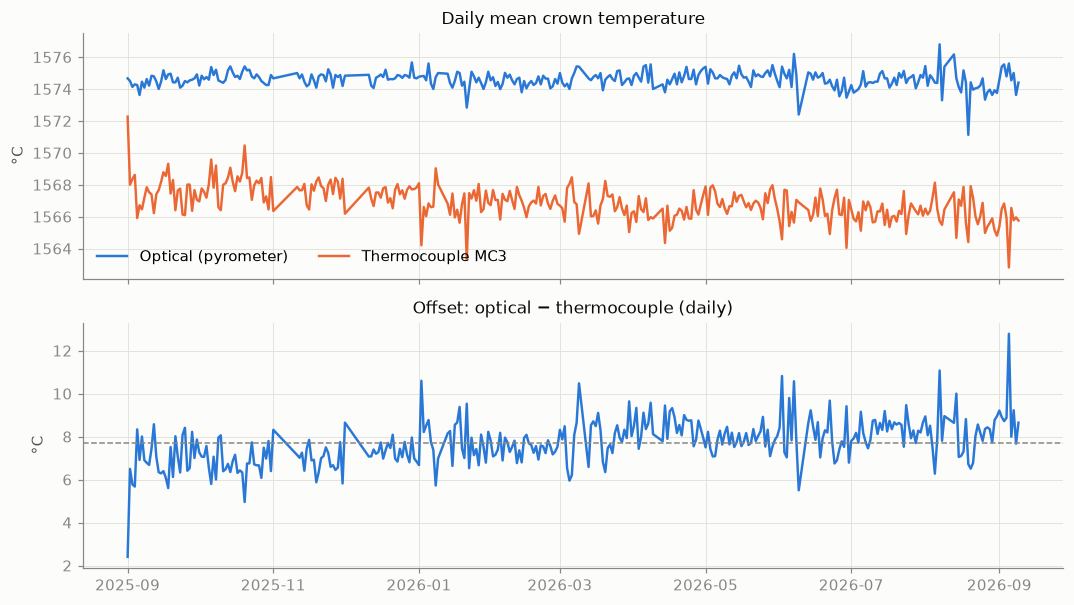

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True)
ax[0].plot(dd.index, dd.opt_temp, color=BLUE, label='Optical (pyrometer)')
ax[0].plot(dd.index, dd.crown_tc, color=ORANGE, label='Thermocouple MC3')
ax[0].set_ylabel('°C'); ax[0].set_title('Daily mean crown temperature'); ax[0].legend(loc='lower left', ncol=2)
ax[1].plot(dd.index, dd.offset, color=BLUE)
ax[1].axhline(dd.offset.mean(), color=MUTED, lw=1, ls='--')
ax[1].set_ylabel('°C'); ax[1].set_title('Offset: optical − thermocouple (daily)')
plt.tight_layout(); plt.show()

**Finding:**
- The offset is fairly stable at about **+7.6 °C** (daily sd about 1 °C), but it drifts from +6.9 to +8.8 °C over the year.
- The two signals barely move together hour to hour (r ≈ 0.03). Optical is held almost flat at ~1574.5 °C, because operators fire to keep it there, and it is read by hand as a whole number.
- **Decision (per plant guidance):** optical is the main crown temperature. The TC is used only as (a) a gap-filler, `opt ≈ TC + monthly offset`, and (b) a continuous 1-min feature for checking how the furnace responds.
- **Modelling caveat:** optical barely varies (daily sd ~0.5 °C), so history can't show what happens if the crown setpoint is lowered. That has to come from a step trial.

## 7. Clean data → daily SFC reconciliation with the client baseline

In [10]:
d = dp.build_daily(q)
dp.write_processed(q, d)
x = d[d.day_complete & d.base_sfc.notna()]
r = x.sfc / x.base_sfc
print('complete baseline days:', len(x), '| SFC ratio ours/client: median %.4f  p05 %.4f  p95 %.4f' % (r.median(), r.quantile(.05), r.quantile(.95)))
print('NCV source:', d.ncv_source.value_counts().to_dict(), '| incomplete days:', int((~d.day_complete).sum()))
x.loc[(r-1).abs() > 0.03, ['sfc','base_sfc','ng_scm','base_ng_scm','ncv_used','base_ncv']].round(1)

complete baseline days: 329 | SFC ratio ours/client: median 0.9987  p05 0.9848  p95 1.0127
NCV source: {'meter': 351, 'baseline': 44} | incomplete days: 36


,sfc,base_sfc,ng_scm,base_ng_scm,ncv_used,base_ncv
date,,,,,,
2025-09-26,1629.8,1576.4,7696.0,7433.0,9726.2,9726.2
2026-02-24,1537.7,1617.5,7471.2,7924.0,9696.4,9678.0
2026-04-22,1538.1,1602.6,7854.9,8177.0,9650.8,9695.9
2026-04-23,1515.3,1627.4,7469.8,8101.0,9689.4,9738.9
2026-05-01,1645.1,1749.5,7476.0,7938.0,10202.5,10318.3
2026-06-03,1491.4,1590.2,7259.1,7801.0,9911.8,9955.8


Recomputed SFC matches the client's daily SFC within about ±1.5% (median 0.999). The few days that differ by more than 3% come from the DCS gas total differing from the SAP/meter gas total.

In [11]:
m = d.groupby(d.index.to_period('M')).agg(draw_t=('draw_kg', lambda s: s.mean()/1000), sfc=('sfc','mean'), ncv=('ncv_used','mean'),
        ng_scm=('ng_scm','mean'), bb_kwh=('bb_kwh','mean'), mb_kwh=('mb_kwh','mean'), afr=('afr','mean'),
        opt=('opt_temp','mean'), crown_tc=('crown_tc','mean'), mb3=('mb3_temp','mean'), cullet=('cullet_pct','mean'), seeds=('seed_count','mean'))
m.round(1)

,draw_t,sfc,ncv,ng_scm,bb_kwh,mb_kwh,afr,opt,crown_tc,mb3,cullet,seeds
date,,,,,,,,,,,,
2025-09,57.2,1539.5,9538.0,7689.6,10868.9,6180.2,12.0,1574.5,1567.6,1320.3,20.0,15.6
2025-10,57.4,1542.0,9486.2,7749.6,9382.4,7972.5,12.0,1574.8,1568.0,1319.1,19.0,11.7
2025-11,58.3,1564.9,9337.7,8099.8,9197.4,8941.5,11.9,1574.7,1567.9,1319.7,17.0,16.1
2025-12,59.0,1556.3,9423.9,8083.7,9147.8,8945.2,11.9,1574.8,1567.4,1319.7,17.0,15.8
2026-01,58.1,1558.5,9824.0,7674.3,9083.7,8458.0,12.3,1574.6,1567.3,1321.1,16.0,12.6
2026-02,55.9,1596.8,9576.4,7919.6,8182.1,7320.9,12.1,1574.5,1567.0,1321.0,16.0,12.3
2026-03,57.2,1552.0,9676.5,7723.8,8925.9,7303.6,12.2,1574.7,1567.0,1320.0,16.0,16.0
2026-04,57.8,1571.5,9834.9,7842.7,8628.4,7321.8,12.4,1574.7,1566.6,1319.9,19.0,15.6
2026-05,59.0,1552.2,10150.5,7609.4,9168.6,7315.8,12.9,1574.8,1567.0,1320.1,18.0,12.7


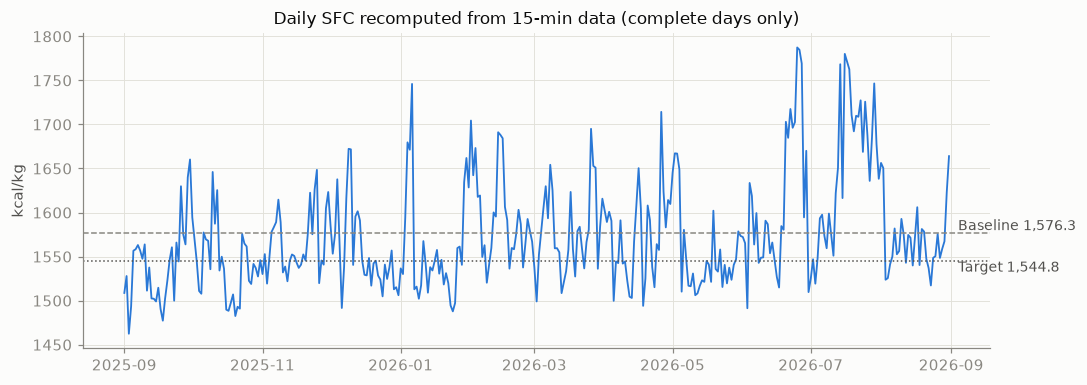

In [12]:
dc = d[d.day_complete]
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(dc.index, dc.sfc, color=BLUE, lw=1.2)
ax.axhline(1576.3, color=MUTED, lw=1, ls='--'); ax.axhline(1544.8, color=INK2, lw=1, ls=':')
x_end = dc.index.max() + pd.Timedelta(days=4)
ax.text(x_end, 1576.3, 'Baseline 1,576.3', color=INK2, fontsize=9, va='bottom')
ax.text(x_end, 1544.8, 'Target 1,544.8', color=INK2, fontsize=9, va='top')
ax.set_ylabel('kcal/kg'); ax.set_title('Daily SFC recomputed from 15-min data (complete days only)')
plt.tight_layout(); plt.show()

## 8. First signals for the 2% (to be developed in later notebooks)

In [13]:
v = q.dropna(subset=['ng_scm','ncv']).copy()
v['heat'] = v.ng_scm * v.ncv
cv = lambda s: 100 * s.std() / s.mean()
print('15-min variability (CV%%): NCV %.1f | NG %.1f | gas heat input %.1f' % (cv(v.ncv), cv(v.ng_scm), cv(v.heat)))
print('corr dNCV(t) vs dNG(t+15min): %.3f   (≈0 means gas is NOT re-set after NCV moves)' % v.ncv.diff().corr(v.ng_scm.diff().shift(-1)))
print('corr NCV vs NG level: 15-min %.2f | daily %.2f' % (v.ncv.corr(v.ng_scm), d.ncv_used.corr(d.ng_scm)))
print('NCV step size per 15 min: median %.0f, p90 %.0f kcal/SCM' % (v.ncv.diff().abs().median(), v.ncv.diff().abs().quantile(.9)))
print('AFR (air/gas) quantiles:', q.afr.quantile([.05,.5,.95]).round(2).to_dict())
print('Seed count: mean %.1f, max %d, days > 30 spec: %d of %d' % (d.seed_count.mean(), d.seed_count.max(), (d.seed_count>30).sum(), len(d)))
print('Cullet % distinct values:', sorted(d.cullet_pct.unique()), '(changes about monthly)')

15-min variability (CV%): NCV 4.7 | NG 6.4 | gas heat input 4.5
corr dNCV(t) vs dNG(t+15min): -0.015   (≈0 means gas is NOT re-set after NCV moves)
corr NCV vs NG level: 15-min -0.71 | daily -0.73
NCV step size per 15 min: median 27, p90 122 kcal/SCM
AFR (air/gas) quantiles: {0.05: 11.23, 0.5: 12.17, 0.95: 13.25}
Seed count: mean 14.8, max 31, days > 30 spec: 1 of 395
Cullet % distinct values: [np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0)] (changes about monthly)


In [14]:
# The 15-min NG has a regular sawtooth -> aliasing of the regenerator reversal cycle
x = q.ng_scm - q.ng_scm.rolling(8, center=True).mean()
print('NG detrended autocorrelation, lags 1-8 (x15 min):', [round(x.autocorr(l), 2) for l in range(1, 9)])
for rule in ['h', '2h', '4h']:
    hh = q[['ng_scm', 'ncv']].resample(rule).mean().dropna()
    heat = hh.ng_scm * hh.ncv
    print('%-3s corr dNCV(t) vs dNG(t+1) %.2f | level corr %.2f | CV%%: NCV %.1f  NG %.1f  heat %.1f' % (rule,
          hh.ncv.diff().corr(hh.ng_scm.diff().shift(-1)), hh.ncv.corr(hh.ng_scm), 100*hh.ncv.std()/hh.ncv.mean(),
          100*hh.ng_scm.std()/hh.ng_scm.mean(), 100*heat.std()/heat.mean()))
hh = q[['ng_scm', 'ncv']].resample('h').mean().dropna()
dev = hh - hh.groupby(hh.index.normalize()).transform('mean')
slope = np.polyfit(dev.ncv, dev.ng_scm, 1)[0] * 100
ideal = -hh.ng_scm.mean() / hh.ncv.mean() * 100
print('Within-day: NG change per +100 kcal/SCM NCV = %.3f SCM/15min; perfect heat compensation = %.3f -> %.0f%% compensated' % (slope, ideal, 100*slope/ideal))

NG detrended autocorrelation, lags 1-8 (x15 min): [np.float64(-0.3), np.float64(-0.28), np.float64(0.17), np.float64(0.14), np.float64(-0.28), np.float64(-0.3), np.float64(0.74), np.float64(-0.33)]
h   corr dNCV(t) vs dNG(t+1) -0.29 | level corr -0.80 | CV%: NCV 4.6  NG 5.7  heat 3.4
2h  corr dNCV(t) vs dNG(t+1) -0.30 | level corr -0.82 | CV%: NCV 4.6  NG 5.6  heat 3.1
4h  corr dNCV(t) vs dNG(t+1) -0.12 | level corr -0.85 | CV%: NCV 4.5  NG 5.4  heat 2.8
Within-day: NG change per +100 kcal/SCM NCV = -0.635 SCM/15min; perfect heat compensation = -0.869 -> 73% compensated


In [15]:
# Air per unit of gas heat: is combustion air scaled with NCV?
ha = q[['sec_air','ng_scm','ncv']].resample('h').mean().dropna()
ha['air_per_mcal'] = ha.sec_air / (ha.ng_scm * ha.ncv / 1000)
print('hourly corr AFR vs NCV: %.2f' % (ha.sec_air/ha.ng_scm).corr(ha.ncv))
print('air per Mcal gas heat: median %.3f, sd %.3f SCM/Mcal  (stoichiometric ~1.1 for natural gas -> excess air ~%.0f%%)' % (
      ha.air_per_mcal.median(), ha.air_per_mcal.std(), 100*(ha.air_per_mcal.median()/1.1 - 1)))
ha.air_per_mcal.groupby(ha.index.to_period('M')).mean().round(3).to_frame('air_per_mcal').T

hourly corr AFR vs NCV: 0.88
air per Mcal gas heat: median 1.268, sd 0.028 SCM/Mcal  (stoichiometric ~1.1 for natural gas -> excess air ~15%)


ts,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08,2026-09
air_per_mcal,1.257,1.27,1.267,1.251,1.265,1.261,1.262,1.265,1.277,1.291,1.275,1.276


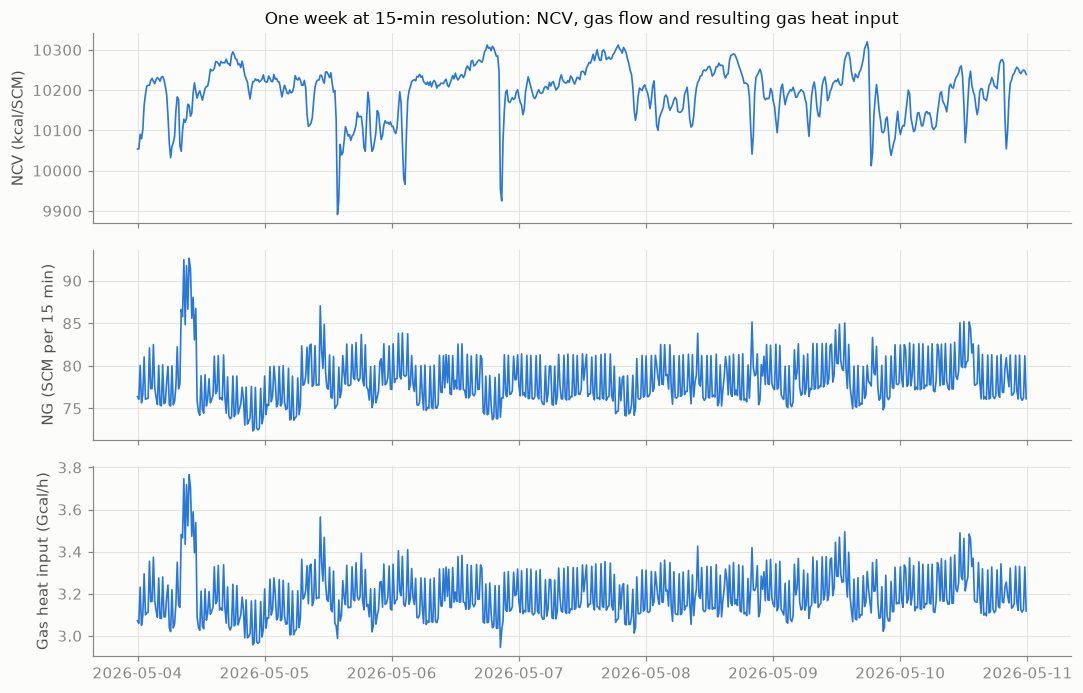

In [16]:
wk = q.loc['2026-05-04':'2026-05-10'].copy(); wk['heat_gcal'] = wk.ng_scm*wk.ncv/1e6*4  # Gcal/h
fig, ax = plt.subplots(3, 1, figsize=(10, 6.4), sharex=True)
for a_, col, lab in [(ax[0],'ncv','NCV (kcal/SCM)'), (ax[1],'ng_scm','NG (SCM per 15 min)'), (ax[2],'heat_gcal','Gas heat input (Gcal/h)')]:
    a_.plot(wk.index, wk[col], color=BLUE, lw=1.1); a_.set_ylabel(lab)
ax[0].set_title('One week at 15-min resolution: NCV, gas flow and resulting gas heat input')
plt.tight_layout(); plt.show()

**Signals:**
1. **NCV compensation is partial and lagged.** Gas flow follows the NCV level (hourly r ≈ −0.80). Within a day, NG changes by about 73% of what exact heat compensation needs, with roughly a 1-hour lag (ΔNCV vs next-hour ΔNG r ≈ −0.29). So gas heat input still drifts with NCV (hourly CV ~3.4%).
   - **The 15-min NG has a sawtooth:** autocorrelation peaks at lag 7 (~105 min), which looks like the regenerator reversal (~20–21 min) aliased by the 15-min sampling. 15-min NG is therefore not a clean signal. **Model gas at 1-hour resolution**, or get 1-min NG from DCS. Ask the plant for the reversal time and whether the 15-min values are snapshots or averages.
2. **AFR median about 12.2, and it tracks NCV** (hourly r ≈ 0.88). Air per Mcal of gas heat is held at ~1.27 SCM/Mcal against a stoichiometric value of ~1.1, so excess air is about 15%. Air already follows heat; the lever is lowering the air-per-Mcal target. Needs flue O₂ and gas composition to confirm.
3. **Large quality headroom:** seeds average ~15 against a spec of 30, so there is likely room to lower the optical crown setpoint. This needs a controlled trial (see section 6).
4. Melter boost is fixed. Barrier boost varies (Aug-26 back to ~10,400 kWh/day) and is the electrical lever.
5. Cullet only changes about once a month (16–20%), so it can't explain much day-to-day variation.